In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akash2907/bird-species-classification")

print("Path to dataset files:", path)

100%|██████████| 1.37G/1.37G [00:08<00:00, 166MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/akash2907/bird-species-classification/versions/1


In [6]:
! cp -r /root/.cache/kagglehub/datasets/akash2907/bird-species-classification/versions/1 /content/dataset

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np

# Split The Data

In [8]:
train_path = "/content/dataset/train_data/train_data"
test_path = "/content/dataset/test_data/test_data"

In [140]:
imgage_size = (224 , 224)
batch_size = 16
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.08,
    subset="training",
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.08,
    subset="validation",
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=imgage_size,
    batch_size=batch_size,
    seed = seed
)

Found 150 files belonging to 16 classes.
Using 138 files for training.
Found 150 files belonging to 16 classes.
Using 12 files for validation.
Found 157 files belonging to 16 classes.


In [133]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 16
['blasti', 'bonegl', 'brhkyt', 'cbrtsh', 'cmnmyn', 'gretit', 'hilpig', 'himbul', 'himgri', 'hsparo', 'indvul', 'jglowl', 'lbicrw', 'mgprob', 'rebimg', 'wcrsrt']


## Aututone

In [141]:
AutoTune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AutoTune)
validation_ds = validation_ds.cache().prefetch(buffer_size=AutoTune)
test_ds = test_ds.cache().prefetch(buffer_size=AutoTune)

# Showing A Sample

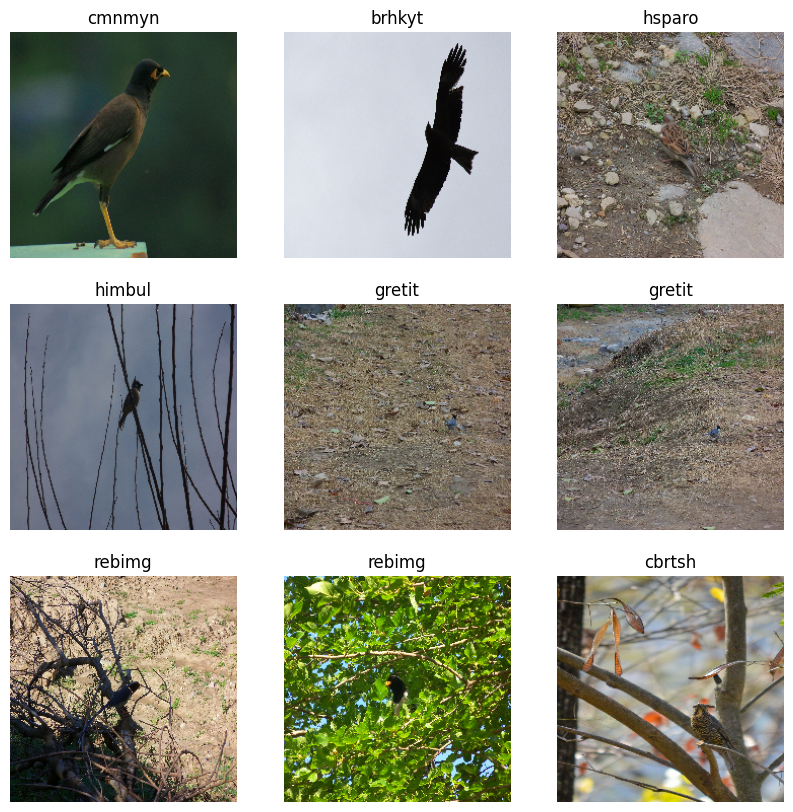

In [30]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# Baseline CNN

In [142]:
Augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

In [143]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    Augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3, 3), padding='same',use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
        
    layers.GlobalAveragePooling2D(),
        
    layers.BatchNormalization(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.6),
    
    layers.Dense(len(class_names), activation='softmax')
    
])

In [144]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_33 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_24 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 16)             │           272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920 (7.50 KB)

 Trainable params: 1,792 (7.00 KB)

 Non-trainable params: 128 (512.00 B)

In [147]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds, validation_data=validation_ds, epochs=100, callbacks=[early_stopping], verbose=1)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2681 - loss: 2.2582 - val_accuracy: 0.3333 - val_loss: 2.0968
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2971 - loss: 2.1365 - val_accuracy: 0.3333 - val_loss: 2.1466
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2826 - loss: 2.2179 - val_accuracy: 0.3333 - val_loss: 2.1873
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2899 - loss: 2.1572 - val_accuracy: 0.3333 - val_loss: 2.2383
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2536 - loss: 2.2097 - val_accuracy: 0.3333 - val_loss: 2.1740
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2174 - loss: 2.2259 - val_accuracy: 0.3333 - val_loss: 2.0881
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2899 - loss: 2.1579 - val_accuracy: 0.2500 - val_loss: 2.1211
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2971 - loss: 2.1347 - val_accuracy: 0.3333 - val_loss:

In [149]:
loss , acc = model.evaluate(test_ds)
print("Accuracy: ", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2675 - loss: 2.3952
Accuracy:  0.2675159275531769


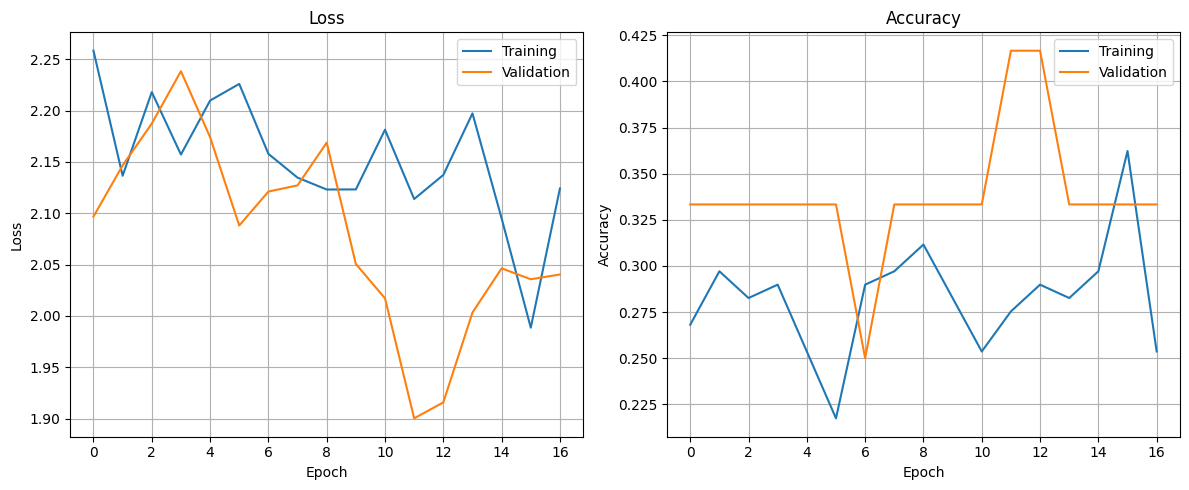

In [150]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()